## Extrenal Data with noise -pinn with no ICs

---
We train a PINN for the three-body problem using noisy observations from  **non physical orbits**, without providing any initial conditions. The motivation for this setup stems from observations in previous experiments: when trained on sparse, high-noise data without prescribed initial conditions, PINNs often converge to solutions whose inferred initial conditions correspond to different periodic orbits. This behavior suggests that the network may exploit the underlying dynamical structure of the system and motivates further investigation into its ability to recover or identify periodic solutions.

* A softening parameter, eps = 10⁻⁹, is introduced in the gravitational interaction terms to prevent numerical singularities when two bodies approach very small separations.

* *The output-layer biases are initialized to nonzero values centered around [−0.2,0.2,0,0,0.2,−0.2], with a seed-dependent random perturbation in the range [−0.05,0.05]. This initialization prevents the network from producing nearly zero-valued outputs at t=0, which would place the bodies unrealistically close together and lead to excessively large residuals in the governing equations.*

* A fixed random seed is supplied to the weight initializer
  (initializer = tf.keras.initializers.GlorotNormal(seed=seed))
  to ensure deterministic network initialization and improve the reproducibility of training results. *Also different seeds applied for noisy data and collocation points to ensure the best posisible reproducibility.*

#Training Procedure
---
1. Train the PINN using sparse noisy observational data without providing initial conditions.

2. Extract the initial conditions inferred by the trained network.

3. Use the inferred initial conditions as an initial guess in a least-squares optimization procedure to identify a nearby periodic orbit.
**Important:** The least-squares refinement requires a reasonable initial estimate of the orbit period. Poor period estimates can cause the optimization to fail or converge to nonphysical solutions, including zero or negative periods.

4. Integrate the equations of motion numerically using the refined initial conditions and validate the resulting orbit.

***Observations***
* By varying the random seed used for network initialization, the PINN may converge to different solutions. In many cases, the inferred initial conditions lead, after least-squares refinement, to periodic orbits. This suggests that the training process can explore multiple regions of the solution space and may provide a mechanism for identifying distinct periodic three-body trajectories.

* The recovered periodic solutions frequently belong to distinct orbit families,
  indicating that the training process can explore multiple regions of the
  solution space despite being supplied only with noisy observations.

* Empirical tests indicate that the learning rate has a significant influence
  on both reproducibility and solution diversity. For relatively large learning
  rates (e.g., 10⁻³), repeated runs may converge to substantially different
  inferred trajectories and, after refinement, to different periodic-orbit
  families.

* In contrast, smaller learning rates (e.g., 10⁻⁴) tend to produce highly
  reproducible results. Repeated runs with identical seeds, data, and network
  initialization converge to nearly identical PINN trajectories and yield
  refined periodic orbits belonging to the same family.

* These observations are consistent with the hypothesis that the PINN loss
  landscape contains multiple attractive basins. Larger learning rates appear
  to promote exploration across different basins, whereas smaller learning
  rates favor convergence within a single basin of attraction.

* Although these findings are empirical and do not constitute proof of a
  multi-basin optimization landscape, they suggest that optimization
  hyperparameters may play an important role in the discovery of distinct
  periodic solutions of the three-body problem.




In [ ]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

## IMPORTS

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

# Training

Set the default float type to float64
Init_net_seed ===>  6
Global_seed ===>  137
noise_seed ===>  137
sum(idx) = 77003
sum(y_obs) = -0.7537159727596129
noise norm = 0.27513280145178975
train_x_all shape = (76, 1)
train_x_all sum   = 37.5078125
train_x_all norm  = 5.180347337308209
Compiling model...
'compile' took 0.000291 s

last layer is: <Dense name=dense_3, built=True>


Model: "fnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 64)                │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 6)                 │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,838 (69.05 KB)

 Trainable params: 8,838 (69.05 KB)

 Non-trainable params: 0 (0.00 B)

old bias: [0. 0. 0. 0. 0. 0.]
new bias: [-0.19618356  0.18432709 -0.01309328 -0.01255032  0.2487445  -0.18672437]


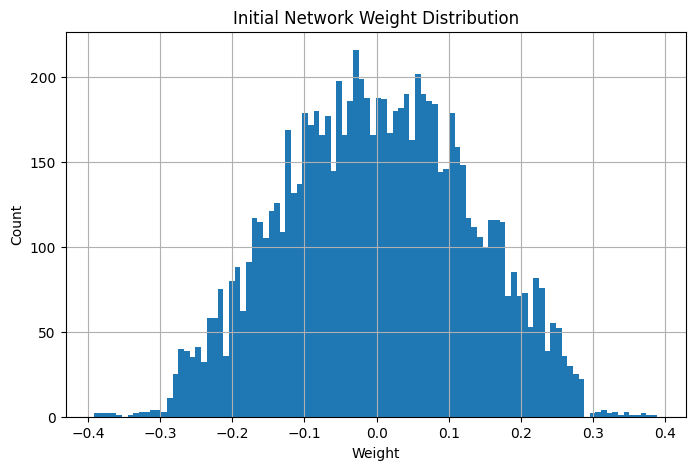

sum = 10.793984154810918
norm = 11.970427308032678
Training model...

Step      Train loss                                                                                                                  Test loss                                                                                                                   Test metric
0         [8.94e+01, 3.22e+02, 7.90e+01, 2.90e+02, 2.98e+01, 7.59e+00, 5.40e-01, 3.81e-01, 4.02e-01, 7.11e-02, 5.52e+00, 4.33e-01]    [9.07e+01, 3.70e+02, 9.18e+01, 3.46e+02, 2.33e+01, 3.13e+00, 5.40e-01, 3.81e-01, 4.02e-01, 7.11e-02, 5.52e+00, 4.33e-01]    []  
1000      [6.81e-01, 2.20e+00, 6.58e-01, 1.66e+00, 2.55e+00, 8.62e-02, 1.32e+00, 3.61e+00, 6.28e-01, 2.56e+00, 4.81e+00, 2.60e-01]    [6.06e-01, 1.97e+00, 6.89e-01, 1.59e+00, 2.48e+00, 6.42e-02, 1.32e+00, 3.61e+00, 6.28e-01, 2.56e+00, 4.81e+00, 2.60e-01]    []  
2000      [6.44e-01, 1.49e+00, 4.01e-01, 1.40e+00, 1.99e+00, 2.24e-02, 1.87e+00, 3.26e+00, 7.06e-01, 2.62e+00, 4.73e+00, 2.10e-01]    

In [ ]:



dde.config.set_default_float("float64")

Init_net_seed=6   #change to get different network initializations

Global_seed=137  #keep fixed to have same collocation points for pde residues

noise_seed=137  # keep fixed to have same noisy data in every test

print("Init_net_seed ===> ",Init_net_seed)
print("Global_seed ===> ",Global_seed)
print("noise_seed ===> ",noise_seed)
dde.config.set_random_seed(Global_seed)
np.random.seed(Global_seed)
tf.random.set_seed(Global_seed)

# ============================================================
# Constants
# ============================================================
G = 1.0
m = [1.0, 1.0, 1.0]

endTime =1


num_domain = 64
num_boundary = 12
num_test = 100


layer_size = [1] + [64]*3 + [6]
activation = "sin"
initializer =tf.keras.initializers.GlorotNormal(seed=Init_net_seed)
#initializer ="Glorot normal" #"Glorot uniform" "Glorot normal"# "He normal" #

iterations =18000
learning_rate = 1e-4
loss_weights=[1]*6+[10]*6
optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0001,weight_decay=0.004)
noise_lvl=0.2  #noise level

eps = 1e-9


# ============================================================
# NUMERICAL SOLUTION with scipy integrator
# ============================================================

def three_body_numeric(t, y):

    x1,y1,vx1,vy1,x2,y2,vx2,vy2,x3,y3,vx3,vy3 = y

    r12 = np.sqrt((x1-x2)**2 + (y1-y2)**2) + eps
    r13 = np.sqrt((x1-x3)**2 + (y1-y3)**2) + eps
    r23 = np.sqrt((x2-x3)**2 + (y2-y3)**2) + eps

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    return [vx1,vy1,ax1,ay1,
            vx2,vy2,ax2,ay2,
            vx3,vy3,ax3,ay3]


# ============================================================
# SYNTHETIC NOISY MEASUREMENTS
# ============================================================

num_obs = 30
noise_level = noise_lvl
T=endTime

# Independent RNG for noisy data
rng_noise = np.random.default_rng(noise_seed)

t_eval = np.linspace(0,endTime,5000)

idx = np.sort(
    rng_noise.choice(len(t_eval), num_obs, replace=False)
)

#three circular orbits
t_obs = t_eval[idx][:,None]
r1=0.2
r2=0.1
r3=0.1
#True data
omega=2*np.pi/T
x1_n=r1*np.sin(omega*t_eval)
y1_n=r1*np.cos(omega*t_eval)
x2_n=r2*np.sin(-omega*t_eval)
y2_n=r2*np.cos(-omega*t_eval)
x3_n=r3*np.sin(-omega*t_eval)
y3_n=r3*np.cos(-omega*t_eval)


y_obs_true = np.vstack([
x1_n[idx],y1_n[idx],
x2_n[idx],y2_n[idx],
x3_n[idx],y3_n[idx]
]).T

noise = noise_level*np.std(y_obs_true, axis=0)*rng_noise.standard_normal(y_obs_true.shape)


y_obs = y_obs_true + noise

#debug-code
print("sum(idx) =", np.sum(idx))
print("sum(y_obs) =", np.sum(y_obs))
print("noise norm =", np.linalg.norm(noise))

# ============================================================
# PINN PDE
# ============================================================

def three_body_ode_second(t,y):

    x1,y1,x2,y2,x3,y3 = [y[:,i:i+1] for i in range(6)]

    r12 = tf.sqrt((x1-x2)**2 + (y1-y2)**2 )+eps
    r13 = tf.sqrt((x1-x3)**2 + (y1-y3)**2 )+eps
    r23 = tf.sqrt((x2-x3)**2 + (y2-y3)**2 )+eps

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    x1_tt = dde.grad.hessian(y,t,component=0,i=0,j=0)
    y1_tt = dde.grad.hessian(y,t,component=1,i=0,j=0)
    x2_tt = dde.grad.hessian(y,t,component=2,i=0,j=0)
    y2_tt = dde.grad.hessian(y,t,component=3,i=0,j=0)
    x3_tt = dde.grad.hessian(y,t,component=4,i=0,j=0)
    y3_tt = dde.grad.hessian(y,t,component=5,i=0,j=0)

    return [
    (x1_tt-ax1),
    (y1_tt-ay1),
    (x2_tt-ax2),
    (y2_tt-ay2),
    (x3_tt-ax3),
    (y3_tt-ay3)
    ]

# ============================================================
# Geometry
# ============================================================

geom = dde.geometry.TimeDomain(0,endTime)

# observation constraints
observe_x1 = dde.PointSetBC(t_obs,y_obs[:,0:1],component=0)
observe_y1 = dde.PointSetBC(t_obs,y_obs[:,1:2],component=1)
observe_x2 = dde.PointSetBC(t_obs,y_obs[:,2:3],component=2)
observe_y2 = dde.PointSetBC(t_obs,y_obs[:,3:4],component=3)
observe_x3 = dde.PointSetBC(t_obs,y_obs[:,4:5],component=4)
observe_y3 = dde.PointSetBC(t_obs,y_obs[:,5:6],component=5)

data = dde.data.PDE(
geom,
three_body_ode_second,
[ observe_x1,observe_y1,observe_x2,observe_y2,observe_x3,observe_y3],
num_domain=num_domain,
num_boundary=num_boundary,
num_test=num_test
)

#==== debug - code ======================================
#print("train_x_all shape:", data.train_x_all.shape)
#print("\nFirst 100 collocation points:")
#print(data.train_x_all[:100])
print("train_x_all shape =", data.train_x_all.shape)
print("train_x_all sum   =", np.sum(data.train_x_all))
print("train_x_all norm  =", np.linalg.norm(data.train_x_all))
#======================================================

# ============================================================
# NETWORK
# ============================================================

net = dde.nn.FNN(layer_size,activation,initializer)


model = dde.Model(data,net)

model.compile(optimizer=optimizer,loss_weights=loss_weights)
#model.compile("adam",lr=learning_rate,loss_weights=loss_weights)

###############################################################
# Change bias in last layer according to seed
###############################################################

model.predict([[0.0]])   # dummy predict

last_layer = model.net.layers[-1]

print("last layer is:", last_layer)

model.net.summary()

w, b = last_layer.get_weights()

print("old bias:", b)

base_bias = np.array([-0.2, 0.2, 0, 0, 0.2, -0.2])

rng = np.random.default_rng(Init_net_seed) # use independent random machine

b = base_bias + rng.uniform(-0.05, 0.05, size=6)

last_layer.set_weights([w, b])

print("new bias:", b)
###############################################################


# Output initial weight destribution

# INITIAL WEIGHTS HISTOGRAM
all_weights = []

for layer in model.net.layers:

    w,b = layer.get_weights()

    all_weights.append(w.flatten())

all_weights = np.concatenate(all_weights)

plt.figure(figsize=(8,5))
plt.hist(all_weights,bins=100)
plt.title("Initial Network Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.grid(True)
plt.show()

#weights check
w_all = []

for layer in model.net.layers:
    w, b = layer.get_weights()
    w_all.append(w.flatten())

w_all = np.concatenate(w_all)

print("sum =", np.sum(w_all))
print("norm =", np.linalg.norm(w_all))

losshistory,train_state = model.train(iterations=iterations)

#model.compile("L-BFGS")
#losshistory,train_state = model.train()




# Plot training and test losses together with the PINN-predicted orbits

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


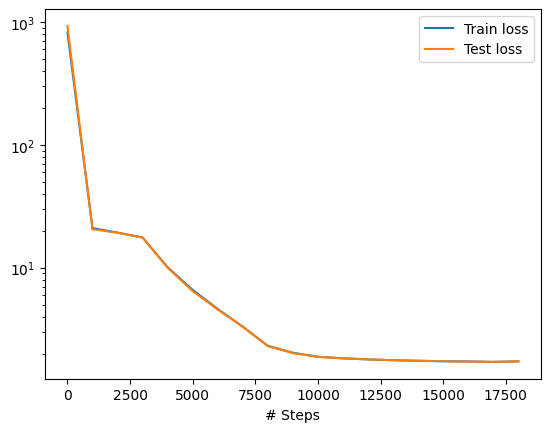

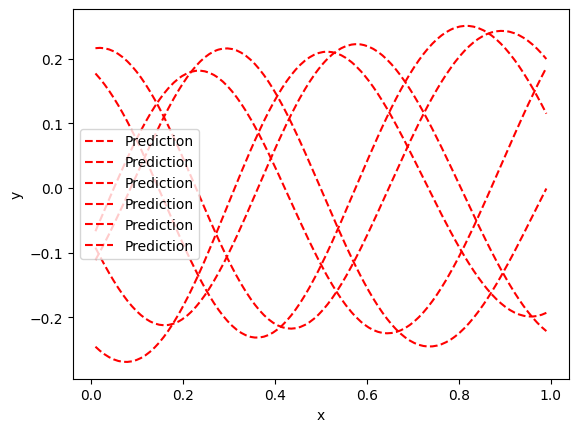

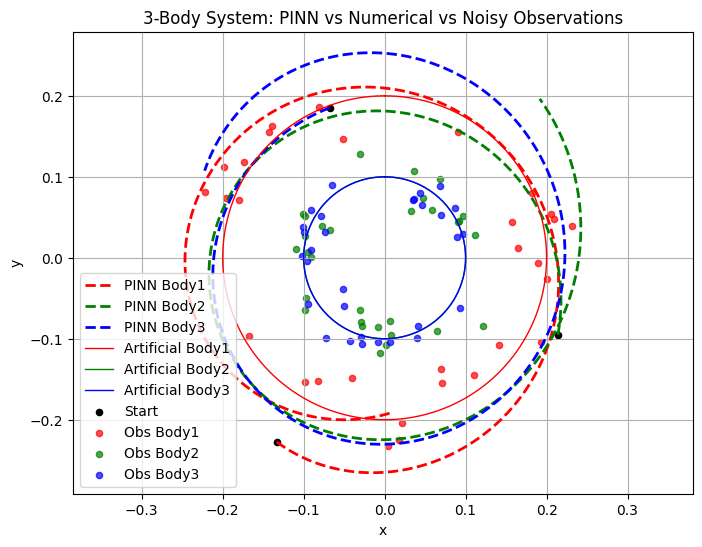

In [ ]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# ============================================================
# PINN PREDICTION
# ============================================================

t_test = np.linspace(0,endTime,5000)[:,None]

y_pred = model.predict(t_test)

x1,y1 = y_pred[:,0],y_pred[:,1]
x2,y2 = y_pred[:,2],y_pred[:,3]
x3,y3 = y_pred[:,4],y_pred[:,5]

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(8,6))

#plot pinn prediction
plt.plot(x1,y1,'r--',lw=2,label="PINN Body1")
plt.plot(x2,y2,'g--',lw=2,label="PINN Body2")
plt.plot(x3,y3,'b--',lw=2,label="PINN Body3")

#plot Artificial orbits
plt.plot(x1_n,y1_n,'r-',lw=1,label="Artificial Body1")
plt.plot(x2_n,y2_n,'g-',lw=1,label="Artificial Body2")
plt.plot(x3_n,y3_n,'b-',lw=1,label="Artificial Body3")


#starting points
plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=20, label='Start')

# noisy measurements
plt.scatter(y_obs[:,0],y_obs[:,1],c='red',s=20,alpha=0.7,label="Obs Body1")
plt.scatter(y_obs[:,2],y_obs[:,3],c='green',s=20,alpha=0.7,label="Obs Body2")
plt.scatter(y_obs[:,4],y_obs[:,5],c='blue',s=20,alpha=0.7,label="Obs Body3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.title("3-Body System: PINN vs Numerical vs Noisy Observations")

plt.show()

##Use Automatic Differentiation (AD) to Compute Velocities and Extract the Initial Conditions Predicted by the PINN

In [ ]:
# ============================================================
# using autodiff for velocities
# ============================================================

#RESTORE endTime
endTime=1
t_test = np.linspace(0, endTime, 5000)[:, None]

# --- compute PINN positions + velocities with autodiff ---
t_tf = tf.convert_to_tensor(t_test)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred = model.net(t_tf)

# Jacobian gives derivatives of each output wrt time
dy_dt = tape.batch_jacobian(y_pred, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:,:,0]

y_pred = y_pred.numpy()
dy_dt = dy_dt.numpy()

# PINN positions
x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1_p, vy1_p = dy_dt[:,0], dy_dt[:,1]
vx2_p, vy2_p = dy_dt[:,2], dy_dt[:,3]
vx3_p, vy3_p = dy_dt[:,4], dy_dt[:,5]


#print pinn inital conditions...
print("pinn inital conditions...")
print("               x0,      y0,      vx0  ,       vy0")
print("body_1    ", x1[0]," ",y1[0]," ",vx1_p[0]," ",vy1_p[0])
print("body_2    ", x2[0]," ",y2[0]," ",vx2_p[0]," ",vy2_p[0])
print("body_3    ", x3[0]," ",y3[0]," ",vx3_p[0]," ",vy3_p[0])

pinn inital conditions...
               x0,      y0,      vx0  ,       vy0
body_1     -0.133245004928066   -0.22740400664760171   1.1523887105123207   -0.8569237220114981
body_2     0.21401464005447335   -0.09518016463200735   0.29238787566234303   1.6576848231032115
body_3     -0.06793776282157332   0.18525302006171196   -1.4828068526840759   -0.5834645386464354


# Least-Squares Refinement of PINN-Predicted Initial Conditions

In [ ]:
#pinn ICs

y0 = np.array([
    x1[0], y1[0],
    x2[0], y2[0],
    x3[0], y3[0],

    vx1_p[0], vy1_p[0],
    vx2_p[0], vy2_p[0],
    vx3_p[0], vy3_p[0]
])


#function for least squares method

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import numpy as np

def refine_orbit(y0, T_guess, verbose=2):

    # --------------------------------
    # Three-body equations
    # --------------------------------
    def three_body(t, y):

        # y = [x1,y1,x2,y2,x3,y3,vx1,vy1,vx2,vy2,vx3,vy3]

        dydt = np.zeros_like(y)

        r = y[:6].reshape(3,2)
        v = y[6:].reshape(3,2)

        dydt[:6] = v.flatten()

        a = np.zeros((3,2))

        for i in range(3):
            for j in range(3):
                if i != j:
                    diff = r[j] - r[i]
                    dist = np.linalg.norm(diff)
                    a[i] += diff / dist**3

        dydt[6:] = a.flatten()

        return dydt

    # --------------------------------
    # Shooting residual
    # --------------------------------
    def shooting_error(vars):

        y0_new = vars[:-1]
        T = vars[-1]

        sol = solve_ivp(
            three_body,
            [0, T],
            y0_new,
            rtol=1e-9,
            atol=1e-9
        )

        yT = sol.y[:, -1]

        return yT - y0_new

    # --------------------------------
    # Least-squares optimization
    # --------------------------------
    vars0 = np.concatenate([y0, [T_guess]])

    result = least_squares(
        shooting_error,
        vars0,
        verbose=verbose,
        xtol=1e-10
    )

    y0_refined = result.x[:-1]
    T_refined = result.x[-1]

    error_norm = np.linalg.norm(
        shooting_error(result.x)
    )


    # --------------------------------
    # Print results
    # --------------------------------
    print("\n==============================")
    print("Least-Squares Refinement")
    print("==============================")

    print("Refined period:", T_refined)
    print("Error norm:", error_norm)

    print("\nRefined initial conditions:\n")

    labels = [
        "x1","y1","x2","y2","x3","y3",
        "vx1","vy1","vx2","vy2","vx3","vy3"
    ]

    for name, val in zip(labels, y0_refined):
        print(f"{name:>4} = {val:.16f}")

    print("==============================\n")

    return y0_refined, T_refined, error_norm, result

T_guess=0.7

y0_refined, T_refined, error_norm, result = refine_orbit(
    y0,
    T_guess=T_guess,verbose=2
)



   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.4418e+00                                    1.38e+02    
       1              5         4.2938e-01      4.01e+00       4.44e-02       6.18e+01    
       2              6         1.0988e-01      3.20e-01       8.89e-02       3.71e+01    
       3              7         2.8960e-02      8.09e-02       8.89e-02       3.70e+01    
       4              9         1.0707e-03      2.79e-02       2.22e-02       7.70e+00    
       5             10         1.8277e-04      8.88e-04       4.44e-02       3.49e+00    
       6             13         1.9895e-06      1.81e-04       5.55e-03       7.89e-02    
       7             15         5.2480e-07      1.46e-06       2.78e-03       1.08e-02    
       8             16         4.0167e-07      1.23e-07       5.55e-03       8.88e-02    
       9             17         2.4735e-07      1.54e-07       1.39e-03       6.98e-02    

# Orbit Obtained from the Least-Squares Refined Initial Conditions

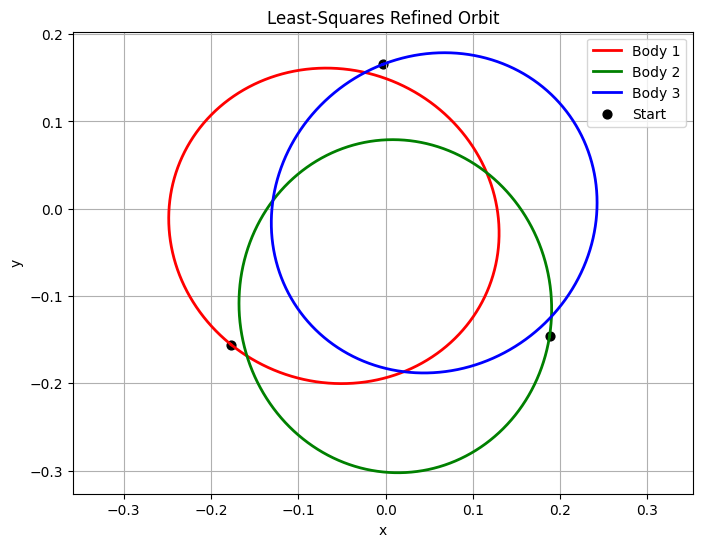

In [ ]:
y0_numeric = np.array([
    y0_refined[0],   # x1
    y0_refined[1],   # y1
    y0_refined[6],   # vx1
    y0_refined[7],   # vy1

    y0_refined[2],   # x2
    y0_refined[3],   # y2
    y0_refined[8],   # vx2
    y0_refined[9],   # vy2

    y0_refined[4],   # x3
    y0_refined[5],   # y3
    y0_refined[10],  # vx3
    y0_refined[11]   # vy3
])

sol = solve_ivp(
    three_body_numeric,
    [0, T_refined],
    y0_numeric,
    t_eval=np.linspace(0, T_refined, 5000),
    rtol=1e-10,
    atol=1e-12
)

# extract trajectories
x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Plot refined orbit
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(x1_n, y1_n, 'r-', lw=2, label='Body 1')
plt.plot(x2_n, y2_n, 'g-', lw=2, label='Body 2')
plt.plot(x3_n, y3_n, 'b-', lw=2, label='Body 3')

# starting points
plt.scatter(
    [x1_n[0], x2_n[0], x3_n[0]],
    [y1_n[0], y2_n[0], y3_n[0]],
    color='k',
    s=40,
    label='Start'
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Least-Squares Refined Orbit")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

#Compare Pinn and least squares initial conditions

In [ ]:
ic_pinn = np.array([
    x1[0], y1[0],vx1_p[0], vy1_p[0],
    x2[0], y2[0],vx2_p[0], vy2_p[0],
    x3[0], y3[0], vx3_p[0], vy3_p[0]


])


ic_refined = np.array([
    y0_refined[0],   # x1
    y0_refined[1],   # y1
    y0_refined[6],   # vx1
    y0_refined[7],   # vy1

    y0_refined[2],   # x2
    y0_refined[3],   # y2
    y0_refined[8],   # vx2
    y0_refined[9],   # vy2

    y0_refined[4],   # x3
    y0_refined[5],   # y3
    y0_refined[10],  # vx3
    y0_refined[11]   # vy3
])


# ==========================================================
# Compare PINN and Least-Squares Initial Conditions
# ==========================================================

labels = [
    "x1","y1","vx1","vy1",
    "x2","y2","vx2","vy2",
    "x3","y3","vx3","vy3"
]

delta = ic_refined - ic_pinn

print("=" * 70)
print("PINN vs Least-Squares Initial Conditions")
print("=" * 70)

print(
    f"{'Variable':<8}"
    f"{'PINN':>15}"
    f"{'LeastSq':>15}"
    f"{'Difference':>15}"
)

print("-" * 70)

for name, pinn_val, ls_val, d in zip(labels, ic_pinn, ic_refined, delta):
    print(
        f"{name:<8}"
        f"{pinn_val:>15.8f}"
        f"{ls_val:>15.8f}"
        f"{d:>15.3e}"
    )

print("-" * 70)

abs_norm = np.linalg.norm(delta)
rel_norm = abs_norm / np.linalg.norm(ic_pinn)

print(f"\nAbsolute correction norm : {abs_norm:.6e}")
print(f"Relative correction norm : {100*rel_norm:.4f}%")

print("\nInterpretation:")
if rel_norm < 0.01:
    print("PINN was extremely close to the periodic orbit.")
elif rel_norm < 0.05:
    print("PINN found a nearby periodic orbit.")
elif rel_norm < 0.20:
    print("PINN found a reasonable approximation.")
else:
    print("Least-squares performed substantial correction.")


PINN vs Least-Squares Initial Conditions
Variable           PINN        LeastSq     Difference
----------------------------------------------------------------------
x1          -0.13324500    -0.17720005     -4.396e-02
y1          -0.22740401    -0.15557102      7.183e-02
vx1          1.15238871     1.22036904      6.798e-02
vy1         -0.85692372    -0.98225729     -1.253e-01
x2           0.21401464     0.18781793     -2.620e-02
y2          -0.09518016    -0.14588158     -5.070e-02
vx2          0.29238788     0.24047525     -5.191e-02
vy2          1.65768482     1.54799923     -1.097e-01
x3          -0.06793776    -0.00308236      6.486e-02
y3           0.18525302     0.16538854     -1.986e-02
vx3         -1.48280685    -1.46084429      2.196e-02
vy3         -0.58346454    -0.56574195      1.772e-02
----------------------------------------------------------------------

Absolute correction norm : 2.253927e-01
Relative correction norm : 8.1769%

Interpretation:
PINN found a reasonabl